In [1]:
import numpy as np
import cvxpy as cp
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
# Force a global black background theme for all notebook plots
plt.style.use('dark_background')

In [2]:
# ==========================================
# 1. US Asset Universe & Realistic ESG Data
# ==========================================
# Top 50 US Equities spanning various sectors to simulate the S&P 500
us_tickers = {
    'AAPL': 'Tech', 'MSFT': 'Tech', 'NVDA': 'Tech', 'AVGO': 'Tech', 'ORCL': 'Tech',
    'AMZN': 'Cons Disc', 'TSLA': 'Cons Disc', 'HD': 'Cons Disc', 'MCD': 'Cons Disc', 'NKE': 'Cons Disc',
    'GOOGL': 'Comm', 'META': 'Comm', 'NFLX': 'Comm', 'DIS': 'Comm', 'CMCSA': 'Comm',
    'JPM': 'Fin', 'BAC': 'Fin', 'WFC': 'Fin', 'GS': 'Fin', 'MS': 'Fin',
    'JNJ': 'Health', 'UNH': 'Health', 'LLY': 'Health', 'MRK': 'Health', 'ABBV': 'Health',
    'XOM': 'Energy', 'CVX': 'Energy', 'COP': 'Energy', 'SLB': 'Energy', 'EOG': 'Energy',
    'NEE': 'Util', 'DUK': 'Util', 'SO': 'Util', 'SRE': 'Util', 'AEP': 'Util',
    'LIN': 'Materials', 'SHW': 'Materials', 'FCX': 'Materials', 'NEM': 'Materials', 'ECL': 'Materials',
    'UNP': 'Industrials', 'HON': 'Industrials', 'BA': 'Industrials', 'CAT': 'Industrials', 'GE': 'Industrials',
    'PG': 'Staples', 'KO': 'Staples', 'PEP': 'Staples', 'WMT': 'Staples', 'COST': 'Staples'
}

# Proxy Carbon Intensities (tCO2e per $1M Revenue) based on typical sector averages
sector_carbon_intensity = {
    'Tech': 15, 'Comm': 20, 'Fin': 15, 'Health': 25,
    'Cons Disc': 40, 'Staples': 35,
    'Industrials': 250, 'Materials': 450,
    'Energy': 800, 'Util': 1100
}

tickers = list(us_tickers.keys())

In [3]:
# ==========================================
# 2. Data Fetching Engine
# ==========================================
print("Fetching US Market Data (2020-2024)...")
data = yf.download(tickers, start='2020-01-01', end='2024-01-01', progress=False)

# Handle yfinance multi-index column formatting safely
if isinstance(data.columns, pd.MultiIndex):
    data = data['Close']
else:
    data = data[[col for col in data.columns if 'Close' in col]]
    data.columns = [col.replace('Close', '').strip() for col in data.columns]

# Calculate Daily Returns and Annualized Covariance (assuming 252 trading days)
returns = data.pct_change().dropna()
# Align tickers to successfully downloaded columns
valid_tickers = [t for t in tickers if t in returns.columns]
returns = returns[valid_tickers]

cov_matrix = returns.cov() * 252

# Generate Market-Cap Proxy Benchmark Weights (Heavily skewed towards Tech/Comm like real life)
np.random.seed(42)
raw_weights = np.array([100 if us_tickers[t] in ['Tech', 'Comm'] else 20 for t in valid_tickers]) * np.random.uniform(0.8, 1.2, len(valid_tickers))
benchmark_weights = raw_weights / np.sum(raw_weights)

# Map Carbon Intensities to valid tickers
carbon_intensities = np.array([sector_carbon_intensity[us_tickers[t]] for t in valid_tickers])

Fetching US Market Data (2020-2024)...


In [4]:
# ==========================================
# 3. Climate Portfolio Optimizer
# ==========================================
class ClimatePortfolioOptimizer:
    def __init__(self, covariance_matrix, benchmark_weights, carbon_intensities):
        self.Sigma = covariance_matrix.values
        self.b = np.array(benchmark_weights).reshape(-1, 1)
        self.CI = np.array(carbon_intensities).reshape(-1, 1)
        self.n_assets = self.Sigma.shape[0]

    def optimize_decarbonization(self, reduction_target=0.50):
        w = cp.Variable((self.n_assets, 1))

        benchmark_waci = (self.b.T @ self.CI)[0, 0]
        target_waci = benchmark_waci * (1 - reduction_target)

        # Objective: Minimize Tracking Error Variance: (w - b)^T * Sigma * (w - b)
        active_weights = w - self.b
        tracking_error_variance = cp.quad_form(active_weights, self.Sigma)
        objective = cp.Minimize(tracking_error_variance)

        # Constraints: Fully invested, Long-only, and hard WACI limit
        constraints = [
            cp.sum(w) == 1,
            w >= 0,
            (self.CI.T @ w)[0] <= target_waci
        ]

        prob = cp.Problem(objective, constraints)
        prob.solve(solver=cp.SCS)

        if w.value is None:
            raise ValueError("Optimization failed to converge.")

        optimal_weights = w.value.flatten()

        # Realized ex-ante Tracking Error Volatility (TEV)
        te_variance = prob.value
        te_volatility = np.sqrt(te_variance)

        return optimal_weights, te_volatility, target_waci

# ==========================================
# 4. Execution & Validation
# ==========================================
optimizer = ClimatePortfolioOptimizer(cov_matrix, benchmark_weights, carbon_intensities)

# Scenario 1: Strict 50% Decarbonization Mandate (Paris-Aligned Benchmark standard)
opt_w, te_vol, target_waci = optimizer.optimize_decarbonization(reduction_target=0.50)

portfolio_waci = np.dot(opt_w, carbon_intensities)
benchmark_waci = np.dot(benchmark_weights, carbon_intensities)

print("\n--- Decarbonization Optimization Results ---")
print(f"Benchmark WACI:           {benchmark_waci:.2f} tCO2e/$1M")
print(f"Optimized Portfolio WACI: {portfolio_waci:.2f} tCO2e/$1M")
print(f"WACI Reduction Achieved:  {(1 - portfolio_waci/benchmark_waci)*100:.2f}%")
print(f"Tracking Error (Ex-Ante): {te_vol*100:.2f}%")

if te_vol <= 0.02:
    print("Status: SUCCESS - Tracking error maintained below 2% limit.\n")
else:
    print("Status: WARNING - 50% decarbonization forces tracking error above 2%.\n")

# Compute Efficient Frontier of Decarbonization
reductions = np.linspace(0.0, 0.80, 20)
te_list, waci_list = [], []

for r in reductions:
    try:
        w_temp, te_temp, waci_temp = optimizer.optimize_decarbonization(reduction_target=r)
        te_list.append(te_temp * 100)
        waci_list.append(waci_temp)
    except:
        pass # Stop if the constraint becomes physically infeasible


--- Decarbonization Optimization Results ---
Benchmark WACI:           161.09 tCO2e/$1M
Optimized Portfolio WACI: 80.54 tCO2e/$1M
WACI Reduction Achieved:  50.00%
Tracking Error (Ex-Ante): 1.02%
Status: SUCCESS - Tracking error maintained below 2% limit.



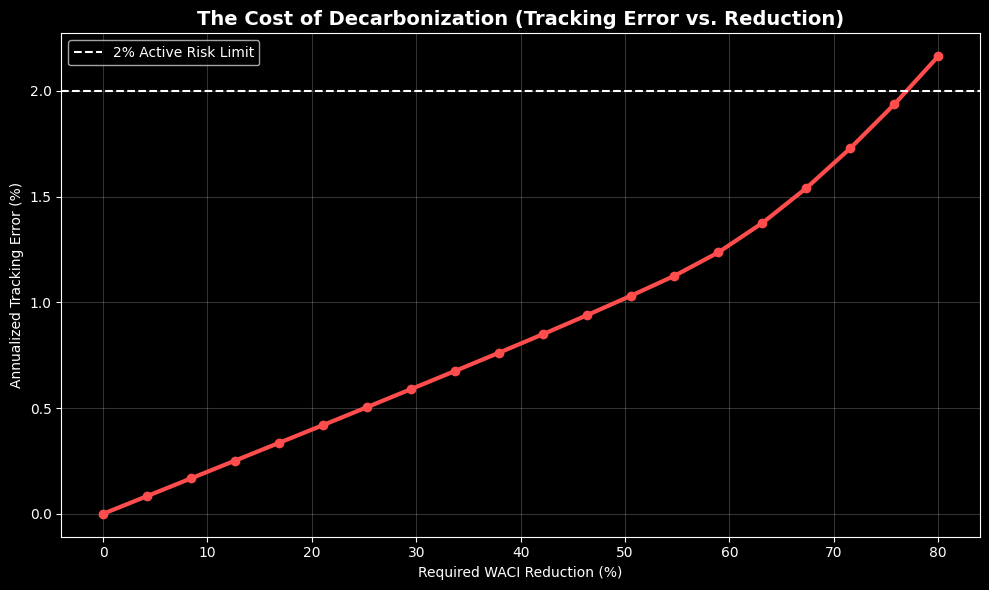

In [5]:
plt.figure(figsize=(10, 6))
plt.plot(reductions[:len(te_list)]*100, te_list, color='#ff4d4d', lw=3, marker='o')
plt.axhline(y=2.0, color='white', linestyle='--', label='2% Active Risk Limit')

plt.title("The Cost of Decarbonization (Tracking Error vs. Reduction)", fontsize=14, fontweight='bold')
plt.xlabel("Required WACI Reduction (%)")
plt.ylabel("Annualized Tracking Error (%)")
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

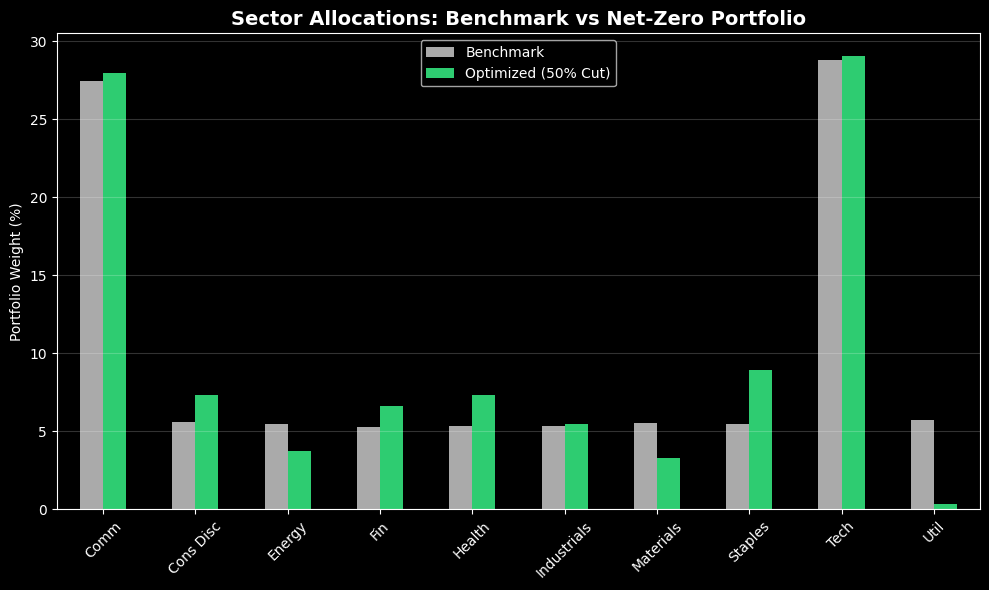

In [6]:
df_weights = pd.DataFrame({
    'Ticker': valid_tickers,
    'Sector': [us_tickers[t] for t in valid_tickers],
    'Benchmark': benchmark_weights,
    'Optimized (50% Cut)': opt_w,
    'CI': carbon_intensities
})
sector_exposure = df_weights.groupby('Sector')[['Benchmark', 'Optimized (50% Cut)']].sum() * 100

plt.figure(figsize=(10, 6))
# Using bright green for the optimized portfolio to contrast with the black background
ax = sector_exposure.plot(kind='bar', color=['#aaaaaa', '#2ecc71'], edgecolor='none', figsize=(10,6), ax=plt.gca())

plt.title("Sector Allocations: Benchmark vs Net-Zero Portfolio", fontsize=14, fontweight='bold')
plt.ylabel("Portfolio Weight (%)")
plt.xlabel("")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.2, axis='y')
plt.legend(["Benchmark", "Optimized (50% Cut)"])
plt.tight_layout()
plt.show()

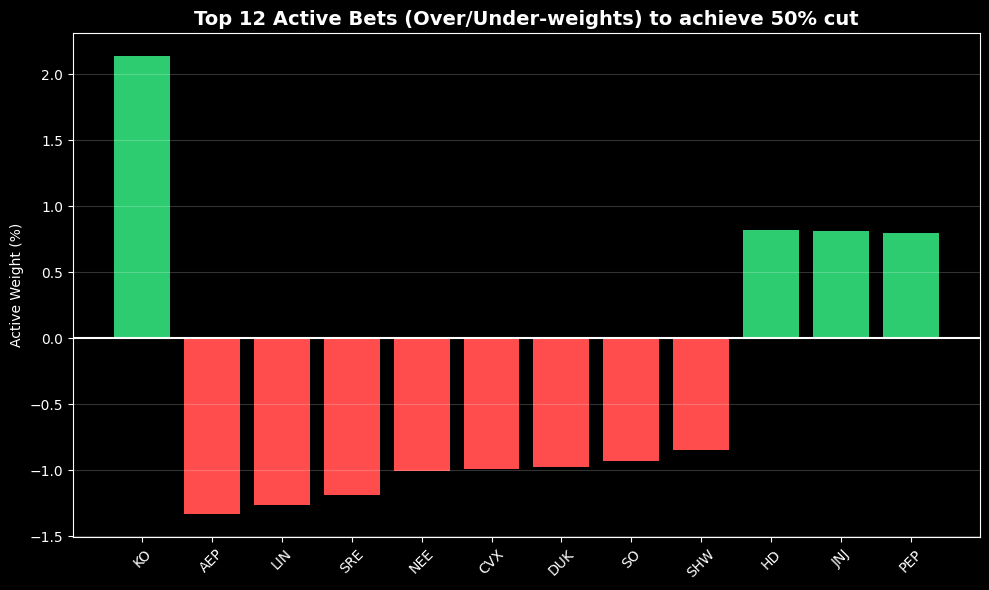

In [7]:
df_weights['Active_Weight'] = (df_weights['Optimized (50% Cut)'] - df_weights['Benchmark']) * 100
top_active = df_weights.reindex(df_weights['Active_Weight'].abs().sort_values(ascending=False).index).head(12)

plt.figure(figsize=(10, 6))
colors = ['#ff4d4d' if x < 0 else '#2ecc71' for x in top_active['Active_Weight']]

plt.bar(top_active['Ticker'], top_active['Active_Weight'], color=colors, edgecolor='none')
plt.axhline(0, color='white', linewidth=1.5)

plt.title("Top 12 Active Bets (Over/Under-weights) to achieve 50% cut", fontsize=14, fontweight='bold')
plt.ylabel("Active Weight (%)")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.show()

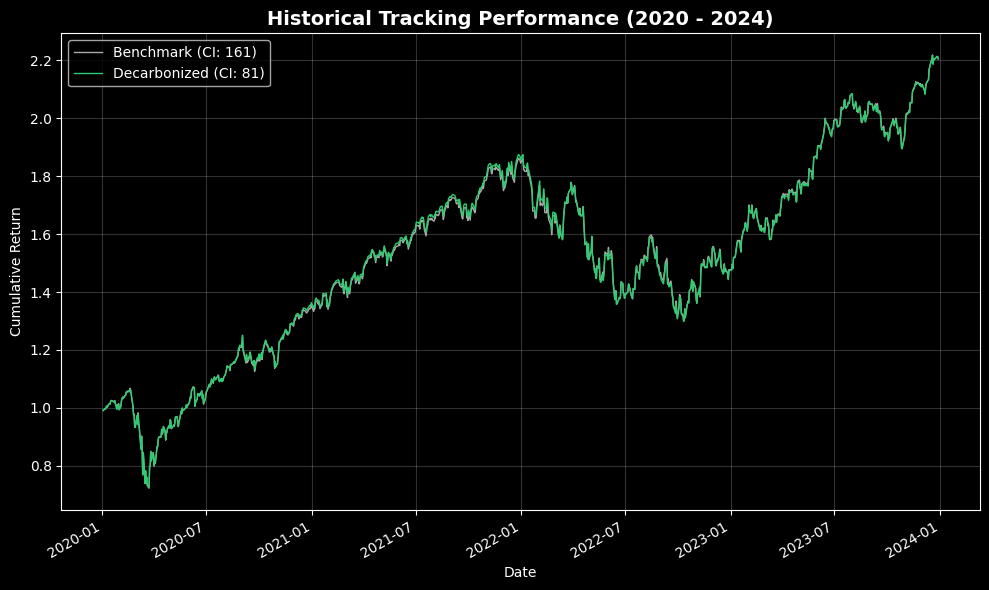

In [8]:
bench_returns = returns.dot(benchmark_weights)
opt_returns = returns.dot(opt_w)

plt.figure(figsize=(10, 6))
(1 + bench_returns).cumprod().plot(color='#aaaaaa', label=f'Benchmark (CI: {benchmark_waci:.0f})', lw=1)
(1 + opt_returns).cumprod().plot(color='#2ecc71', label=f'Decarbonized (CI: {portfolio_waci:.0f})', lw=1)

plt.title("Historical Tracking Performance (2020 - 2024)", fontsize=14, fontweight='bold')
plt.ylabel("Cumulative Return")
plt.xlabel("Date")
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()